In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [15]:
#load processed weather data
weather_df = pd.read_csv('../data/processed/weather_data_processed.csv', parse_dates=['date'])

In [16]:
weather_df['date'] = pd.to_datetime(weather_df['date'])
weather_df.info()
weather_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  10959 non-null  datetime64[us]
 1   YEAR                  10959 non-null  int64         
 2   DOY                   10959 non-null  int64         
 3   state                 10959 non-null  str           
 4   temp_avg              10959 non-null  float64       
 5   temp_max              10959 non-null  float64       
 6   temp_min              10959 non-null  float64       
 7   rainfall              10959 non-null  float64       
 8   humidity              10959 non-null  float64       
 9   solar_radiation       10959 non-null  float64       
 10  wind_speed            10959 non-null  float64       
 11  heat_stress           10959 non-null  int64         
 12  rainfall_7day_avg     10959 non-null  float64       
 13  consecutive_dry_days  10959

,date,YEAR,DOY,state,temp_avg,temp_max,temp_min,rainfall,humidity,solar_radiation,wind_speed,heat_stress,rainfall_7day_avg,consecutive_dry_days,consecutive_hot_days,temp_range,month,risk_label
0,2015-01-01,2015,1,Benue,25.88,34.28,18.35,0.0,39.40,21.11,2.30,0,0.0,1,0,15.93,1,2
1,2015-01-02,2015,2,Benue,24.06,33.75,15.99,0.0,39.66,22.30,3.08,0,0.0,2,0,17.76,1,2
2,2015-01-03,2015,3,Benue,23.49,32.06,16.87,0.0,35.63,17.92,4.04,0,0.0,3,0,15.19,1,2
3,2015-01-04,2015,4,Benue,23.06,31.34,17.29,0.0,29.73,20.46,4.39,0,0.0,4,0,14.05,1,2
4,2015-01-05,2015,5,Benue,21.94,29.39,16.53,0.0,29.82,18.19,4.13,0,0.0,5,0,12.86,1,2


In [17]:
#define features and target 
features = [
    'temp_avg',        #keep - average is less direct than max
    'temp_max',       
    'temp_min',
    'rainfall',        
    'humidity',
    'solar_radiation', #new signal the model can learn from
    'wind_speed',      #new signal
    'temp_range',      #instability indicator
    'month',           #seasonal patterns
    'rainfall_7day_avg' #trend indicator
]

X = weather_df[features]
y = weather_df["risk_label"]

In [18]:
print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nSample features:")
X.head()


Features shape: (10959, 10)
Target distribution:
risk_label
1    3727
0    3618
2    3614
Name: count, dtype: int64

Sample features:


,temp_avg,temp_max,temp_min,rainfall,humidity,solar_radiation,wind_speed,temp_range,month,rainfall_7day_avg
0,25.88,34.28,18.35,0.0,39.40,21.11,2.30,15.93,1,0.0
1,24.06,33.75,15.99,0.0,39.66,22.30,3.08,17.76,1,0.0
2,23.49,32.06,16.87,0.0,35.63,17.92,4.04,15.19,1,0.0
3,23.06,31.34,17.29,0.0,29.73,20.46,4.39,14.05,1,0.0
4,21.94,29.39,16.53,0.0,29.82,18.19,4.13,12.86,1,0.0


In [19]:
#split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    stratify= y,
                                                    random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())
print("\nTesting label distribution:")
print(y_test.value_counts())

Training set size: (8767, 10)
Testing set size: (2192, 10)

Training label distribution:
risk_label
1    2982
0    2894
2    2891
Name: count, dtype: int64

Testing label distribution:
risk_label
1    745
0    724
2    723
Name: count, dtype: int64


In [20]:
#set up and train the random forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Prevents overfitting
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples at leaf node
    random_state=42,
    class_weight='balanced' # Handles unequal class distribution

)

print("Training model...")
rf_model.fit(X_train, y_train)
print("Training complete!")

#make predictions
y_pred = rf_model.predict(X_test)

#basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training model...
Training complete!

Model Accuracy: 94.98%



Classification Report:
               precision    recall  f1-score   support

     Low Risk       0.92      0.96      0.94       724
Moderate Risk       0.96      0.92      0.94       745
    High Risk       0.96      0.96      0.96       723

     accuracy                           0.95      2192
    macro avg       0.95      0.95      0.95      2192
 weighted avg       0.95      0.95      0.95      2192



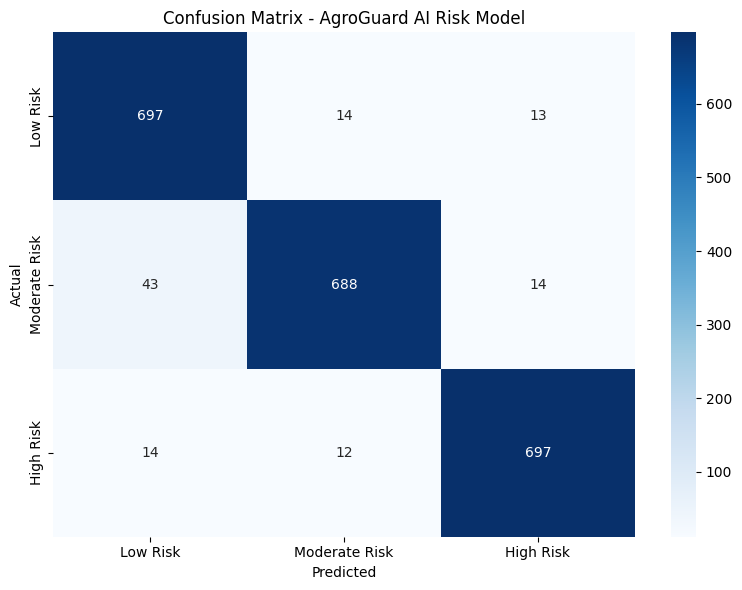


Cross Validation Scores: [0.95574818 0.90328467 0.94708029 0.92837591 0.86125057]
Mean CV Accuracy: 91.91%
Standard Deviation: 3.41%


In [21]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Low Risk', 'Moderate Risk', 'High Risk']
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'Moderate Risk', 'High Risk'],
            yticklabels=['Low Risk', 'Moderate Risk', 'High Risk'])
plt.title('Confusion Matrix - AgroGuard AI Risk Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png')
plt.show()

# Cross validation score for reliability
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"\nCross Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

In [22]:
#feature importance analysis
feature_importances = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)


print("\nFeature Importances:")
print(feature_importances)


Feature Importances:
             feature  importance
4           humidity    0.378056
7         temp_range    0.141086
1           temp_max    0.131119
3           rainfall    0.130900
9  rainfall_7day_avg    0.071219
0           temp_avg    0.052711
2           temp_min    0.048369
8              month    0.019503
6         wind_speed    0.018375
5    solar_radiation    0.008663


C:\Users\Miriam\AppData\Local\Temp\ipykernel_21172\1260589037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='importance', y='feature', palette='viridis')


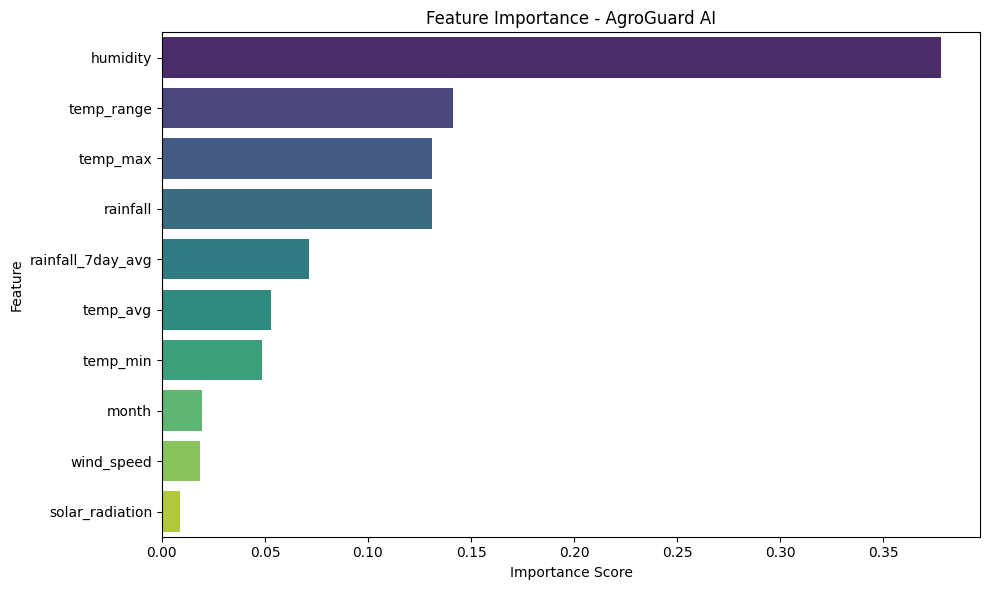

In [23]:
#plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - AgroGuard AI')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../models/feature_importance.png')
plt.show();

Our Random Forest climate risk model achieved 95% accuracy across all three risk categories on unseen test data. Critically, it performs best at detecting high risk conditions - the scenario where a missed prediction would be most damaging to a farmer's livelihood. Precision vs Recall balance - all three classes are balanced between precision and recall, meaning the model is neither over-alerting farmers unnecessarily nor missing real dangers.

Feature Importance Analysis

1. Humidity - 37.8% - by far the dominant factor. This makes agronomic sense for Nigeria. Humidity drives pest outbreaks like fall armyworm, fungal disease, and post-harvest rot. The model discovered this on its own without being told.
2. Temperature Range - 14.1% - the gap between daily max and min temperatures signals weather instability. Wide swings indicate unpredictable conditions.
3. Temperature Max - 13.1% - extreme heat directly stresses crops.
4. Rainfall - 13.1% - almost identical importance to temp max, which reflects how critical rainfall patterns are to Nigerian farming.
5. 7-Day Rainfall Average - 7.1% - the model is picking up on rainfall trends, not just single-day events. This is sophisticated behaviour.

Solar radiation and wind speed contributed least - which also makes sense. These are less directly tied to immediate crop risk in the Nigerian context.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Try with more trees and slightly constrained depth
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,      # More trees for stability
    max_depth=8,           # Slightly shallower to reduce humidity dominance
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced'
)

rf_model_v2.fit(X_train, y_train)
y_pred_v2 = rf_model_v2.predict(X_test)

# Compare
from sklearn.metrics import accuracy_score
print("V1 Test Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("V2 Test Accuracy:", accuracy_score(y_test, y_pred_v2) * 100)

cv_v2 = cross_val_score(rf_model_v2, X, y, cv=5)
print(f"\nV2 CV Scores: {cv_v2}")
print(f"V2 Mean CV: {cv_v2.mean() * 100:.2f}%")
print(f"V2 Std Dev: {cv_v2.std() * 100:.2f}%")

V1 Test Accuracy: 94.98175182481752
V2 Test Accuracy: 93.65875912408758

V2 CV Scores: [0.95255474 0.88822993 0.92107664 0.90009124 0.86627111]
V2 Mean CV: 90.56%
V2 Std Dev: 2.94%


In [25]:
import joblib
import json

# Save final model
joblib.dump(rf_model, '../models/rf_climate_risk_model.pkl')

# Save feature names
with open('../models/feature_names.json', 'w') as f:
    json.dump(features, f)

print("Final Random Forest model saved!")
print(f"Model accuracy: 94.98%")
print(f"Mean CV accuracy: 91.91%")

Final Random Forest model saved!
Model accuracy: 94.98%
Mean CV accuracy: 91.91%
